# Hands-on Week 4
---
## Introduction to Deep Learning and PyTorch


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader


torch.manual_seed(42)
np.random.seed(42)

## Tensors

Tensors are the main data object that pytorch works with. Tensors are multi-dimensional matrices

### 1.1 Creating Tensors
Run the cell below to create a tensor and inspect its properties.

In [2]:
# Creating tensors
a = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])

print(f"Tensor a:\n{a}")
print(f"Shape:  {a.shape}")
print(f"Dtype:  {a.dtype}")
print(f"Device: {a.device}")
print("-" * 40)

# Common operations (mirror NumPy)
print(f"\nSum:         {a.sum()}")
print(f"Mean:        {a.mean():.4f}")
print(f"Shape after T: {a.T.shape}")
print(f"Matrix mul:  \n{a @ a.T}")

Tensor a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape:  torch.Size([2, 3])
Dtype:  torch.float32
Device: cpu
----------------------------------------

Sum:         21.0
Mean:        3.5000
Shape after T: torch.Size([3, 2])
Matrix mul:  
tensor([[14., 32.],
        [32., 77.]])


#### Question 1.1: Tensor Properties

After running the cell above, answer the following:

1. What is the **shape** of `a`? What do the two numbers mean?
2. `a.T` transposes the tensor. What is the shape of `a.T`?
3. Matrix multiplication `a @ a.T` — what shape does the result have, and why?


In [3]:
a.matmul(a.transpose(0,1))

tensor([[14., 32.],
        [32., 77.]])

### Exercises 1.2

Complete the cell below:
- Create a 3×3 identity matrix using `torch.eye()`
- Compute its determinant (hint: `torch.linalg.det()`)
- Create a random tensor of shape (4, 4) and compute its column-wise mean (hint: `dim=0`)

In [4]:
# TODO: Create a 3x3 identity matrix
I = torch.eye(3)
print('Identity matrix:\n', I)

# TODO: Compute the determinant
det = torch.linalg.det(I)  
print('Determinant:', det)

# TODO: Random 4x4 tensor — column-wise mean
R = torch.randn(4, 4)
col_means = R.mean(dim=0)
print('Random tensor:\n', R)
print('Column means:', col_means)

Identity matrix:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
Determinant: tensor(1.)
Random tensor:
 tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]])
Column means: tensor([ 0.2813,  0.3355, -0.0759, -1.0878])


## Part 2: Training a Perceptron with Pytorch

PyTorch is built around two core ideas:
1. **Tensors** — n-dimensional arrays with GPU support
2. **Autograd** — automatic differentiation: call `.backward()` and gradients flow

### The training loop (every DL model follows this)
```
for each batch:
    1. Forward pass:   output = model(input)
    2. Compute loss:   loss   = loss_fn(output, target)
    3. Zero gradients: optimiser.zero_grad()
    4. Backward pass:  loss.backward()          ← autograd!
    5. Update weights: optimiser.step()         ← gradient descent
```

In [5]:
# Generate synthetic data
X_line = torch.linspace(-3, 3, 60).unsqueeze(1)
y_line = 2 * X_line + 1 + 0.4 * torch.randn_like(X_line)

# Model: one linear layer (y = Wx + b)
model = nn.Linear(1, 1)
optimiser = optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
EPOCHS = 1000

for epoch in range(EPOCHS):
    pred = model(X_line)                  # 1. Forward
    loss = loss_fn(pred, y_line)          # 2. Loss
    optimiser.zero_grad()                 # 3. Zero grads
    loss.backward()                       # 4. Backward
    optimiser.step()                      # 5. Update
    losses.append(loss.item())

W_learned = model.weight.item()
b_learned = model.bias.item()
print(f"True:    y = 2.0x + 1.0")
print(f"Learned: y = {W_learned:.3f}x + {b_learned:.3f}")

True:    y = 2.0x + 1.0
Learned: y = 1.951x + 0.965


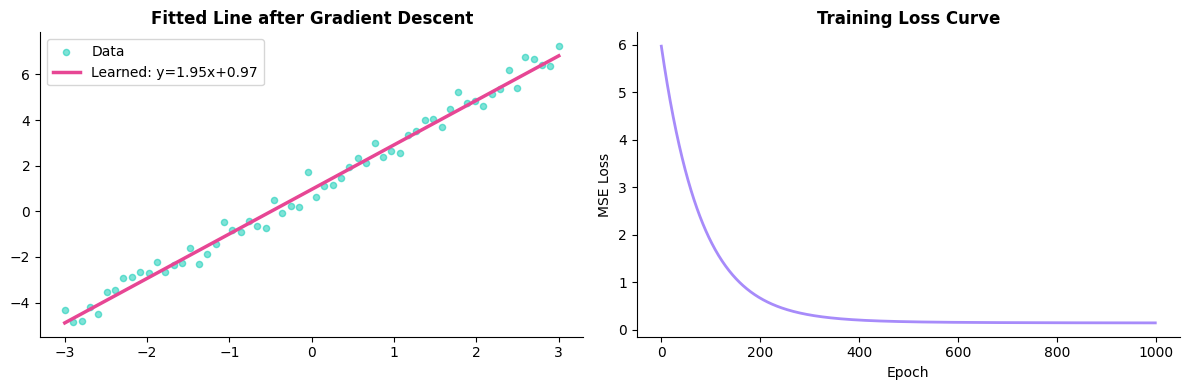

In [6]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_line.numpy(), y_line.numpy(), alpha=0.5, s=20, color="#00C9B1", label="Data")
with torch.no_grad():
    y_fit = model(X_line)
ax1.plot(X_line.numpy(), y_fit.numpy(), color="#E74694", lw=2.5, label=f"Learned: y={W_learned:.2f}x+{b_learned:.2f}")
ax1.set_title("Fitted Line after Gradient Descent", fontweight="bold")
ax1.legend()
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.plot(losses, color="#A78BFA", lw=2)
ax2.set_title("Training Loss Curve", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE Loss")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Question 2.2 — Reading the Loss Curve

Look at the **Training Loss Curve** plot.

1. What shape does the loss curve have? What does this tell you about gradient descent?
2. Does the curve flatten out (converge)? What does convergence mean in this context?
3. **Experiment**: Go back to the training loop, change `lr=0.05` to `lr=0.5`, re-run, and describe what happens to the loss curve. Then try `lr=0.001`. What do you observe?

----

## Part 3: Word Embeddings

### 3.1 From TF-IDF to Embeddings

| | TF-IDF | Word Embeddings |
|---|---|---|
| Representation | Sparse, high-dimensional | Dense, low-dimensional |
| Similarity | Exact word overlap | Semantic proximity |
| Learned? | Fixed formula | Learned during training |
| Analogy possible? | No | king − man + woman ≈ queen |

Each word gets an integer ID, and each ID maps to a **dense vector** (the embedding).
These vectors are learned during training so that semantically similar words cluster together.

### Question 3.1 — Embeddings vs TF-IDF

1. TF-IDF for a 10,000-word vocabulary produces vectors of length 10,000.
   If our embedding dimension is 32, how many parameters does `nn.Embedding(10000, 32)` have?
2. Why is a dense representation often better for neural networks than a sparse one?


In [7]:
# Load the data into Python
texts, labels = [], []
with open("../../data/lang_detection.txt", "r", encoding="utf-8") as f:
    for line in f:
        sentence, label = line.strip().split("\t")
        texts.append(sentence)
        labels.append(label)

y = np.array(labels)

word_corpus = []
for text in texts:
    word_corpus.extend([w.lower() for w in word_tokenize(text) if w.isalpha()])
word_vocab = sorted(list(set(word_corpus)))

In [8]:
word_to_id = {gram: i for i, gram in enumerate(word_vocab)}

In [9]:
def encode(text, max_seq_len=15):
    id_seq = [0] * max_seq_len
    for i, word in enumerate(word_tokenize(text)):
        if i >= max_seq_len:
            break
        if word.isalpha(): 
            id_seq[i] = word_to_id[word.lower()]
    return id_seq

In [10]:
# nn.Embedding is a trainable lookup table:
# vocab_size rows, each row = dense vector for one token
VOCAB_SIZE  = len(word_corpus) + 1
EMBED_DIM   = 32
MAX_SEQ_LEN = 5

token_ids = np.array([encode(text) for text in texts])
token_ids

array([[154, 352,   0, ...,   0,   0,   0],
       [164,  11, 354, ...,   0,   0,   0],
       [310, 174, 137, ...,   0,   0,   0],
       ...,
       [ 76,  32, 280, ...,   0,   0,   0],
       [ 29, 277,  75, ...,   0,   0,   0],
       [333, 132,  61, ...,   0,   0,   0]], shape=(150, 15))

In [11]:
class SentenceDataset(Dataset):
    def __init__(self, texts, labels, max_seq_len=MAX_SEQ_LEN):
        self.texts = texts
        self.labels = labels
        self.max_seq_len = max_seq_len
        unique_labels = sorted(set(labels))
        self.label_to_idx = {label: i for i, label in enumerate(unique_labels)}
        self.num_classes = len(unique_labels)
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        label_id = self.label_to_idx[label]
        token_ids = torch.tensor(encode(text, self.max_seq_len)).long()
        return (
            text,
            token_ids,
            label_id,
        )

texts_train, texts_test, labels_train, labels_test = train_test_split(texts, labels, test_size=0.1)

train_dataset = SentenceDataset(texts_train, labels_train)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)


### Recurrent Neural Networks: the DL alternative to "pooling"

Recurrent neural networks (RNNs) extend feedforward architectures to handle sequential data by maintaining an internal state that persists across input elements. For each element $i=1,\ldots,n$ in a sequence, an RNN receives an input $x_t$ and updates its hidden state $h_t$ based on both the input and the previous hidden state $h_{t-1}$. This recurrent connection enables the network to maintain information about past inputs, making RNNs suitable for processing sequences of arbitrary length.
In its most fundamental form, the transition is defined as $h_t = \tanh(W_{h} h_{t-1} + W_{x} x_t + b)$, where $W_{h}$ and $W_{x}$ are learnable weight matrices

In [12]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.1):
        super(RNNEncoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Disable bias on h2h to avoid doubling the bias term
        self.i2h = nn.Linear(embed_dim, hidden_dim, bias=True)
        self.h2h = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape

        embedded = self.dropout(self.embedding(x))  # regularize embeddings

        # Cleaner device handling — no intermediate .to() copy
        h_t = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        for t in range(seq_len):
            x_t = embedded[:, t, :]
            h_t = torch.tanh(self.i2h(x_t) + self.h2h(h_t))

        return h_t

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(TextClassifier, self).__init__()
        self.rnn = RNNEncoder(vocab_size, embed_dim, hidden_dim)
        self.lin = nn.Linear(embed_dim, num_classes)

    def forward(self, token_ids):
        text_emb = self.rnn(token_ids)
        return self.lin(text_emb)

In [13]:
model = TextClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=EMBED_DIM, num_classes=3)
optimiser = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

DEVICE = "cpu"
EPOCHS = 500
train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for text, token_ids, label in train_dataloader:
        token_ids = token_ids.to(DEVICE)
        label = label.to(DEVICE)
        logits = model(token_ids)                        # (B, num_classes)
        # CrossEntropyLoss expects logits of shape (B, num_classes) and label ids of shape (num_classes,)
        loss = loss_fn(
            logits.view(-1, 3),
            label.view(-1)
        )
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch  50/500  |  Loss: 0.0043
Epoch 100/500  |  Loss: 0.0007
Epoch 150/500  |  Loss: 0.0002
Epoch 200/500  |  Loss: 0.0001
Epoch 250/500  |  Loss: 0.0003
Epoch 300/500  |  Loss: 0.0000
Epoch 350/500  |  Loss: 0.0002
Epoch 400/500  |  Loss: 0.0000
Epoch 450/500  |  Loss: 0.0000
Epoch 500/500  |  Loss: 0.0000

Training complete!


In [14]:
test_dataset = SentenceDataset(texts_test, labels_test)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

In [15]:
correct = 0
incorrect = 0
model.train(False)
for text, token, label in test_dataloader:
    token = token.to(DEVICE)
    label = label.to(DEVICE)
    logits = model(token) 
    pred = torch.argmax(logits, dim=-1)
    correct += int((label == pred).sum())
    incorrect += int((label != pred).sum())

In [16]:
correct / (correct + incorrect) * 100

66.66666666666666